# Chapter 10.5: Monitoring & Observability

## Learning Objectives

By the end of this notebook, you will be able to:

1. Implement **data drift detection** using PSI and KS tests for feature distribution monitoring
2. Identify **model degradation signals** including AUC decay, CTR drops, and latency spikes
3. Build **alerting systems** with threshold-based and anomaly detection approaches
4. Design **monitoring dashboards** with key metrics for recommendation system health
5. Understand Meta's approach to recommendation monitoring at scale
6. Implement a complete monitoring pipeline with drift detection and anomaly alerts
7. Distinguish between **data issues**, **model issues**, and **system issues** in production

## Prerequisites

- Basic statistics (distributions, hypothesis testing)
- Chapter 10.1-10.4 (Serving and experimentation concepts)
- Understanding of recommendation metrics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part10/chapter_10.5_monitoring.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part10/chapter_10.5_monitoring.ipynb)

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from collections import deque, defaultdict
from datetime import datetime, timedelta

np.random.seed(42)

print("All imports successful!")

All imports successful!


## 1. Data Drift Detection

**Data drift** occurs when the distribution of input features changes over time. This is the #1 cause of model degradation in production rec systems.

### Population Stability Index (PSI)

PSI measures the shift between a reference distribution and the current distribution:

$$
\text{PSI} = \sum_{i=1}^{B} (p_i^{\text{current}} - p_i^{\text{reference}}) \cdot \ln\left(\frac{p_i^{\text{current}}}{p_i^{\text{reference}}}\right)
$$

where $B$ is the number of bins.

| PSI Range | Interpretation |
|-----------|---------------|
| < 0.1 | No significant drift |
| 0.1 - 0.2 | Moderate drift, investigate |
| > 0.2 | Significant drift, retrain |

### Kolmogorov-Smirnov Test

The KS test measures the maximum distance between two CDFs:

$$
D = \sup_x |F_{\text{ref}}(x) - F_{\text{current}}(x)|
$$

> **💡 Concept:** Drift can be benign (seasonal changes that the model handles) or harmful (a data pipeline bug that corrupts features). Always pair statistical drift detection with business metric monitoring to distinguish the two.

In [2]:
# Implement drift detection methods

def compute_psi(reference: np.ndarray, current: np.ndarray,
                n_bins: int = 10) -> float:
    """Compute Population Stability Index."""
    # Create bins from reference distribution
    bins = np.percentile(reference, np.linspace(0, 100, n_bins + 1))
    bins[0] = -np.inf
    bins[-1] = np.inf

    # Compute proportions
    ref_counts = np.histogram(reference, bins=bins)[0]
    cur_counts = np.histogram(current, bins=bins)[0]

    # Add small constant to avoid division by zero
    ref_pct = (ref_counts + 1) / (len(reference) + n_bins)
    cur_pct = (cur_counts + 1) / (len(current) + n_bins)

    psi = np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct))
    return float(psi)


def compute_ks_stat(reference: np.ndarray, current: np.ndarray) -> Tuple[float, float]:
    """Compute Kolmogorov-Smirnov statistic and p-value."""
    stat, p_value = stats.ks_2samp(reference, current)
    return float(stat), float(p_value)


class DriftDetector:
    """Multi-feature drift detection system."""

    def __init__(self, feature_names: List[str], psi_threshold: float = 0.2,
                 ks_alpha: float = 0.01):
        self.feature_names = feature_names
        self.psi_threshold = psi_threshold
        self.ks_alpha = ks_alpha
        self.reference_data: Dict[str, np.ndarray] = {}
        self.drift_history: List[Dict] = []

    def set_reference(self, data: Dict[str, np.ndarray]):
        """Set the reference distribution for each feature."""
        self.reference_data = {k: v.copy() for k, v in data.items()}

    def detect(self, current_data: Dict[str, np.ndarray],
               timestamp: str = "") -> Dict:
        """Detect drift in current data."""
        results = {"timestamp": timestamp, "features": {}, "has_drift": False}

        for feature in self.feature_names:
            ref = self.reference_data[feature]
            cur = current_data[feature]

            psi = compute_psi(ref, cur)
            ks_stat, ks_pval = compute_ks_stat(ref, cur)

            drifted = psi > self.psi_threshold or ks_pval < self.ks_alpha
            if drifted:
                results["has_drift"] = True

            results["features"][feature] = {
                "psi": psi,
                "ks_stat": ks_stat,
                "ks_pval": ks_pval,
                "drifted": drifted,
            }

        self.drift_history.append(results)
        return results


# Simulate feature drift over time
np.random.seed(42)

n_samples = 5000
feature_names = ["user_age", "item_price", "session_length", "click_rate", "time_of_day"]

# Reference distribution (training data)
reference = {
    "user_age": np.random.normal(35, 10, n_samples),
    "item_price": np.random.lognormal(3, 1, n_samples),
    "session_length": np.random.exponential(5, n_samples),
    "click_rate": np.random.beta(2, 20, n_samples),
    "time_of_day": np.random.uniform(0, 24, n_samples),
}

detector = DriftDetector(feature_names)
detector.set_reference(reference)

# Simulate 30 days of production data
drift_results_over_time = []
for day in range(30):
    current = {}
    # Day 0-10: stable
    # Day 10-15: gradual drift in user_age (younger users)
    # Day 15-20: item_price spike (sale event)
    # Day 20-30: recovery

    age_shift = 0 if day < 10 else min((day - 10) * 1.5, 8)
    price_mult = 1.0 if day < 15 or day > 20 else 0.5

    current["user_age"] = np.random.normal(35 - age_shift, 10, n_samples)
    current["item_price"] = np.random.lognormal(3, 1, n_samples) * price_mult
    current["session_length"] = np.random.exponential(5, n_samples)
    current["click_rate"] = np.random.beta(2, 20, n_samples)
    current["time_of_day"] = np.random.uniform(0, 24, n_samples)

    result = detector.detect(current, timestamp=f"Day {day}")
    drift_results_over_time.append(result)

# Show results for select days
for day_idx in [5, 12, 17, 25]:
    r = drift_results_over_time[day_idx]
    drifted_features = [f for f, v in r["features"].items() if v["drifted"]]
    print(f"Day {day_idx}: drift={'YES' if r['has_drift'] else 'NO'}, "
          f"drifted features: {drifted_features or 'none'}")
    for feat in drifted_features[:2]:
        v = r["features"][feat]
        print(f"  {feat}: PSI={v['psi']:.4f}, KS={v['ks_stat']:.4f}")

Day 5: drift=NO, drifted features: none
Day 12: drift=YES, drifted features: ['user_age']
  user_age: PSI=0.0984, KS=0.1310
Day 17: drift=YES, drifted features: ['user_age', 'item_price']
  user_age: PSI=0.6270, KS=0.3196
  item_price: PSI=0.4240, KS=0.2674
Day 25: drift=YES, drifted features: ['user_age']
  user_age: PSI=0.6265, KS=0.3244


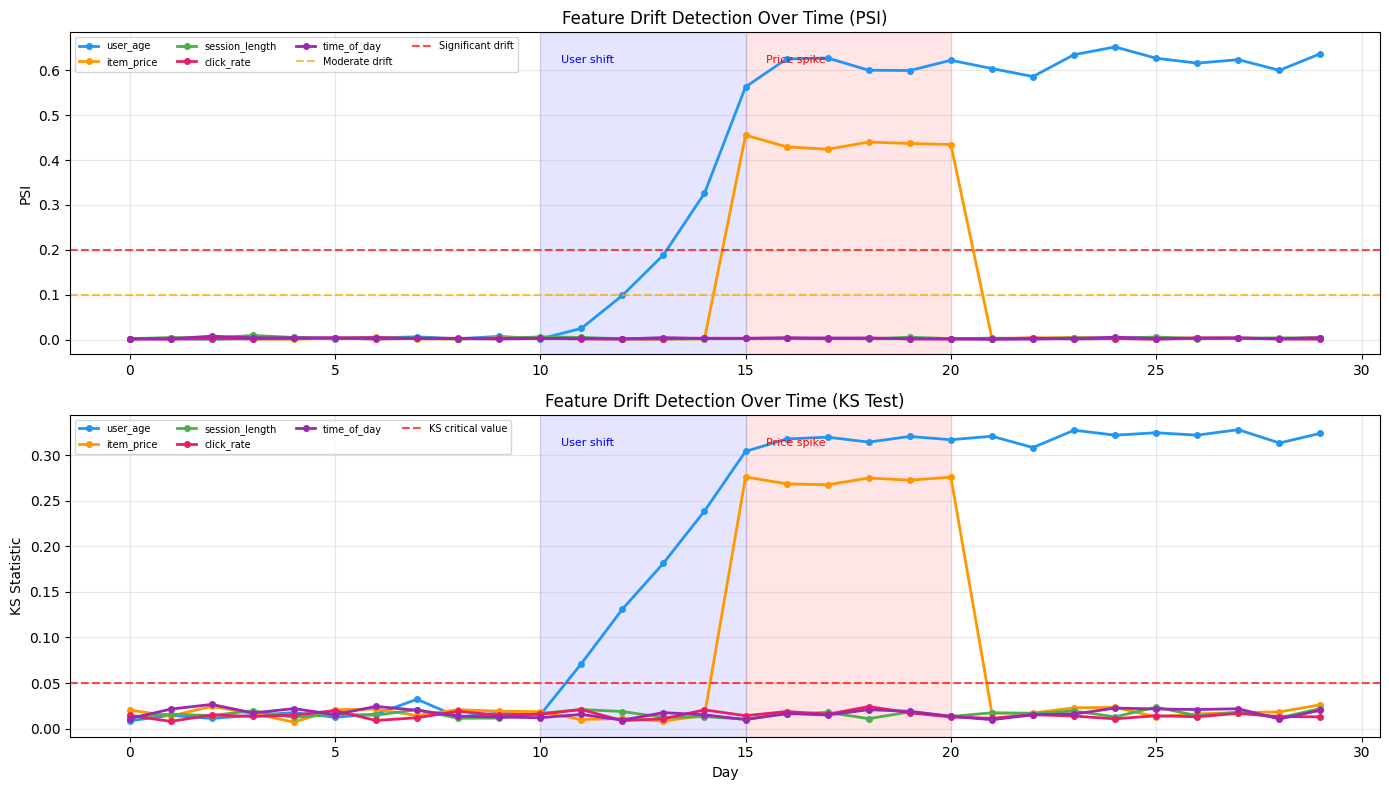

In [3]:
# Visualize drift over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

days = range(30)

# Top: PSI over time for each feature
colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']
for i, feat in enumerate(feature_names):
    psi_values = [drift_results_over_time[d]["features"][feat]["psi"] for d in days]
    axes[0].plot(days, psi_values, linewidth=2, color=colors[i], label=feat, marker='o', markersize=4)

axes[0].axhline(y=0.1, color='orange', linestyle='--', alpha=0.7, label='Moderate drift')
axes[0].axhline(y=0.2, color='red', linestyle='--', alpha=0.7, label='Significant drift')
axes[0].set_ylabel("PSI")
axes[0].set_title("Feature Drift Detection Over Time (PSI)")
axes[0].legend(fontsize=7, ncol=4)
axes[0].grid(alpha=0.3)

# Bottom: KS statistic over time
for i, feat in enumerate(feature_names):
    ks_values = [drift_results_over_time[d]["features"][feat]["ks_stat"] for d in days]
    axes[1].plot(days, ks_values, linewidth=2, color=colors[i], label=feat, marker='o', markersize=4)

axes[1].axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='KS critical value')
axes[1].set_xlabel("Day")
axes[1].set_ylabel("KS Statistic")
axes[1].set_title("Feature Drift Detection Over Time (KS Test)")
axes[1].legend(fontsize=7, ncol=4)
axes[1].grid(alpha=0.3)

# Add event annotations
for ax in axes:
    ax.axvspan(10, 15, alpha=0.1, color='blue', label='_nolegend_')
    ax.axvspan(15, 20, alpha=0.1, color='red', label='_nolegend_')
    ax.text(10.5, ax.get_ylim()[1] * 0.9, 'User shift', fontsize=8, color='blue')
    ax.text(15.5, ax.get_ylim()[1] * 0.9, 'Price spike', fontsize=8, color='red')

plt.tight_layout()
plt.show()

## 2. Model Degradation Signals

Model quality can degrade due to:

1. **Data drift** (distribution shift in features or labels)
2. **Concept drift** (the relationship between features and outcomes changes)
3. **Data quality issues** (pipeline bugs, missing values, stale features)
4. **System issues** (latency spikes causing timeouts, cache failures)

Key monitoring signals:

| Signal | Normal Range | Alert Threshold | Root Cause |
|--------|-------------|----------------|------------|
| Online AUC | 0.75-0.85 | <0.73 | Model/data issue |
| CTR | 4-6% | <3.5% or >8% | Model/UI issue |
| P99 Latency | 50-100ms | >200ms | System issue |
| Error rate | <0.1% | >1% | System issue |
| Null predictions | <0.01% | >0.1% | Data pipeline issue |

> **⚠️ Common Pitfall:** A sudden CTR increase can be as alarming as a decrease. If CTR spikes 50% overnight, it likely means the model is overfitting to clickbait content, not that it suddenly got smarter.

In [4]:
# Simulate model degradation and detection

class ModelMonitor:
    """Monitors model performance metrics over time."""

    def __init__(self, window_size: int = 24):
        self.window_size = window_size  # hours
        self.metrics_history = defaultdict(list)
        self.alerts = []

    def log_metrics(self, timestamp: int, metrics: Dict[str, float]):
        for name, value in metrics.items():
            self.metrics_history[name].append((timestamp, value))

    def check_threshold(self, metric: str, lower: float = None,
                        upper: float = None) -> Optional[Dict]:
        """Check if current metric value is outside thresholds."""
        if metric not in self.metrics_history or len(self.metrics_history[metric]) == 0:
            return None

        current_value = self.metrics_history[metric][-1][1]
        timestamp = self.metrics_history[metric][-1][0]

        if lower is not None and current_value < lower:
            return {"metric": metric, "value": current_value,
                    "threshold": lower, "type": "below_lower",
                    "timestamp": timestamp}
        if upper is not None and current_value > upper:
            return {"metric": metric, "value": current_value,
                    "threshold": upper, "type": "above_upper",
                    "timestamp": timestamp}
        return None

    def check_anomaly(self, metric: str, n_std: float = 3.0) -> Optional[Dict]:
        """Detect anomalies using z-score on rolling window."""
        values = [v for _, v in self.metrics_history[metric]]
        if len(values) < self.window_size + 1:
            return None

        window = values[-(self.window_size + 1):-1]
        current = values[-1]
        mean = np.mean(window)
        std = np.std(window)

        if std == 0:
            return None

        z_score = (current - mean) / std
        if abs(z_score) > n_std:
            return {
                "metric": metric,
                "value": current,
                "z_score": z_score,
                "window_mean": mean,
                "window_std": std,
                "timestamp": self.metrics_history[metric][-1][0]
            }
        return None


# Simulate 30 days of hourly metrics
np.random.seed(42)
n_hours = 30 * 24
hours = np.arange(n_hours)

# Generate realistic metric patterns
def generate_metric_series(base: float, noise_std: float, n: int,
                           anomaly_hours: List[Tuple[int, float]] = None,
                           trend: float = 0.0) -> np.ndarray:
    """Generate a metric time series with optional anomalies."""
    # Base + diurnal pattern + noise + trend
    diurnal = 0.05 * base * np.sin(2 * np.pi * np.arange(n) / 24)
    weekly = 0.03 * base * np.sin(2 * np.pi * np.arange(n) / 168)
    noise = np.random.normal(0, noise_std, n)
    series = base + diurnal + weekly + noise + trend * np.arange(n)

    if anomaly_hours:
        for hour, magnitude in anomaly_hours:
            if hour < n:
                # Anomaly affects a few hours
                for h in range(max(0, hour), min(n, hour + 6)):
                    series[h] += magnitude

    return series


# Metrics with injected anomalies
auc_series = generate_metric_series(
    0.80, 0.005, n_hours,
    anomaly_hours=[(360, -0.05)],  # Day 15: AUC drop
    trend=-0.00001  # Slight degradation over time
)

ctr_series = generate_metric_series(
    0.05, 0.003, n_hours,
    anomaly_hours=[(360, -0.015), (500, 0.025)]  # Day 15: CTR drop, Day 21: CTR spike
)

latency_series = generate_metric_series(
    80, 10, n_hours,
    anomaly_hours=[(200, 100)]  # Day 8: latency spike
)

error_series = generate_metric_series(
    0.001, 0.0005, n_hours,
    anomaly_hours=[(200, 0.05)]  # Day 8: error spike (same time as latency)
)
error_series = np.maximum(error_series, 0)

# Run monitoring
monitor = ModelMonitor(window_size=48)
all_alerts = []

for h in range(n_hours):
    monitor.log_metrics(h, {
        "auc": auc_series[h],
        "ctr": ctr_series[h],
        "latency_p99": latency_series[h],
        "error_rate": error_series[h],
    })

    # Check thresholds
    alerts_this_hour = []
    alert = monitor.check_threshold("auc", lower=0.73)
    if alert:
        alerts_this_hour.append(alert)
    alert = monitor.check_threshold("latency_p99", upper=200)
    if alert:
        alerts_this_hour.append(alert)

    # Check anomalies
    for metric in ["auc", "ctr", "latency_p99", "error_rate"]:
        alert = monitor.check_anomaly(metric, n_std=3.0)
        if alert:
            alerts_this_hour.append(alert)

    all_alerts.extend(alerts_this_hour)

# Summarize alerts
alert_counts = defaultdict(int)
for a in all_alerts:
    alert_counts[a["metric"]] += 1

print(f"Total alerts over 30 days: {len(all_alerts)}")
for metric, count in sorted(alert_counts.items(), key=lambda x: -x[1]):
    print(f"  {metric}: {count} alerts")

Total alerts over 30 days: 25
  error_rate: 9 alerts
  ctr: 8 alerts
  latency_p99: 7 alerts
  auc: 1 alerts


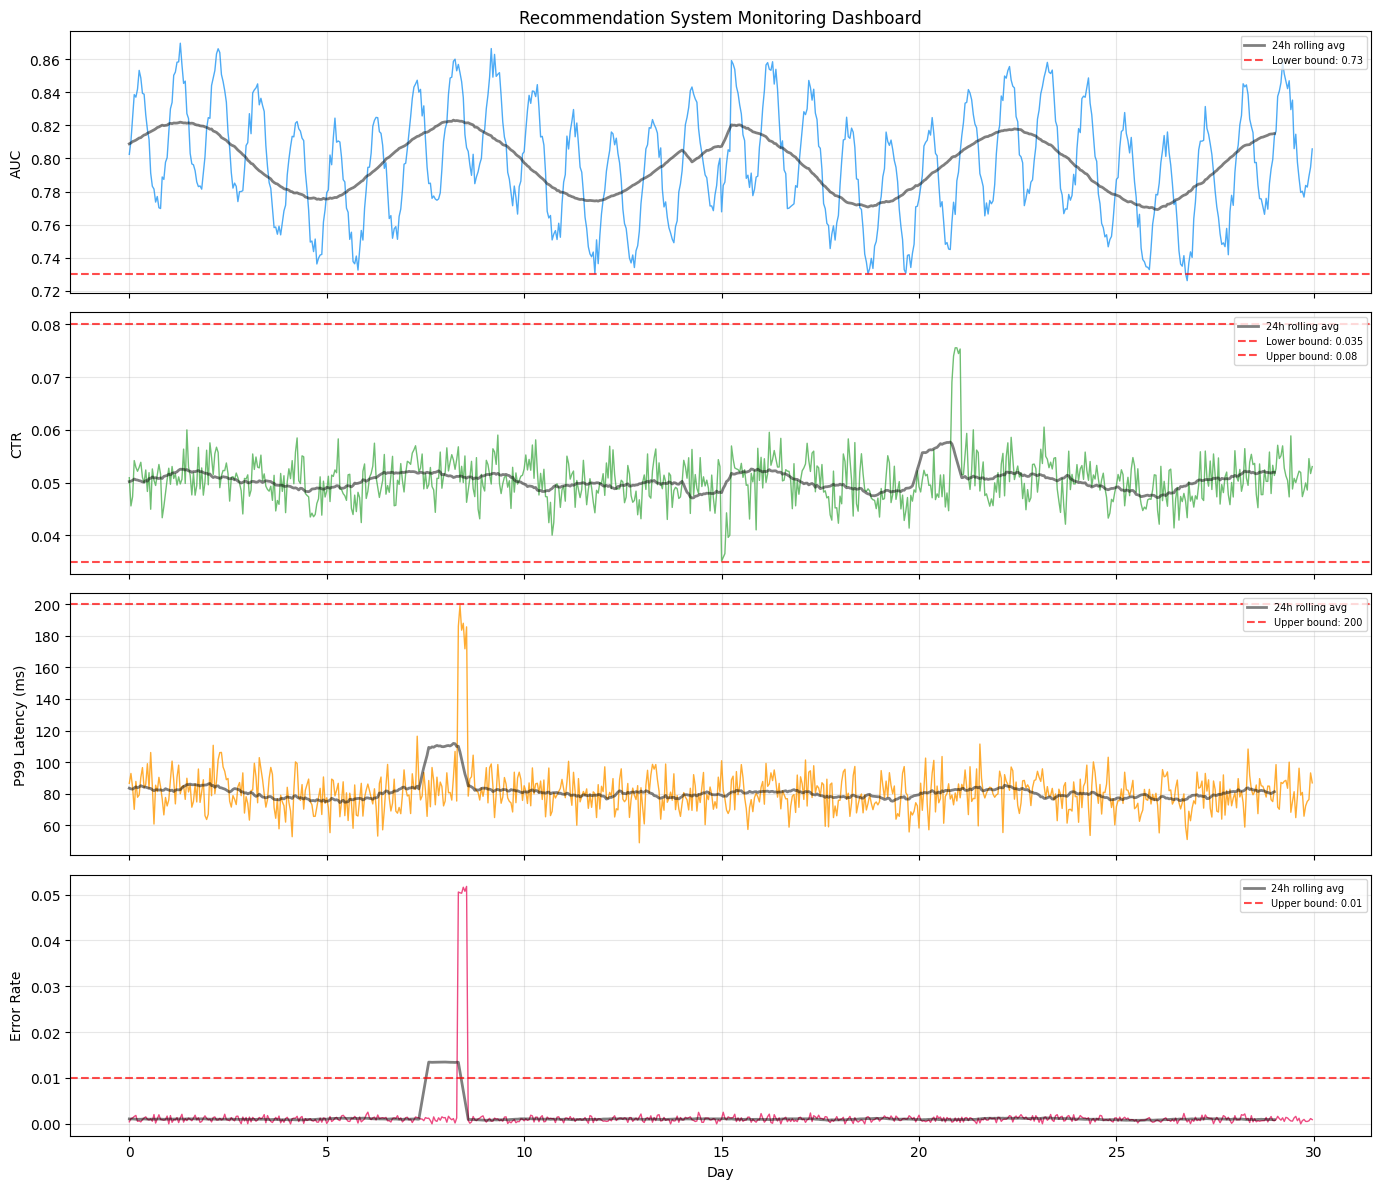

In [5]:
# Monitoring dashboard visualization
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

metrics = [
    ("AUC", auc_series, 0.73, None, '#2196F3'),
    ("CTR", ctr_series, 0.035, 0.08, '#4CAF50'),
    ("P99 Latency (ms)", latency_series, None, 200, '#FF9800'),
    ("Error Rate", error_series, None, 0.01, '#E91E63'),
]

days_x = hours / 24

for i, (name, series, lower, upper, color) in enumerate(metrics):
    axes[i].plot(days_x, series, linewidth=1, color=color, alpha=0.8)

    # Rolling average
    window = 24
    if len(series) > window:
        rolling = np.convolve(series, np.ones(window)/window, mode='valid')
        axes[i].plot(days_x[:len(rolling)], rolling, linewidth=2,
                     color='black', alpha=0.5, label='24h rolling avg')

    if lower is not None:
        axes[i].axhline(y=lower, color='red', linestyle='--', alpha=0.7, label=f'Lower bound: {lower}')
    if upper is not None:
        axes[i].axhline(y=upper, color='red', linestyle='--', alpha=0.7, label=f'Upper bound: {upper}')

    # Mark anomaly periods
    metric_alerts = [a for a in all_alerts if a.get("metric") == name.lower().split()[0]
                     or a.get("metric") == name.lower().replace(" ", "_").replace("(ms)", "").strip()]

    axes[i].set_ylabel(name)
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel("Day")
axes[0].set_title("Recommendation System Monitoring Dashboard")

plt.tight_layout()
plt.show()

## 3. Anomaly Detection for Alerting

Beyond simple thresholds, production systems use **statistical anomaly detection**:

1. **Z-score** on rolling window (simple, works for stationary metrics)
2. **Exponentially Weighted Moving Average (EWMA)**: Adapts to trends
3. **Seasonal Decomposition**: Handles daily/weekly patterns
4. **Isolation Forest / Autoencoder**: For multi-dimensional anomalies

EWMA control chart:

$$
\text{EWMA}_t = \lambda \cdot x_t + (1 - \lambda) \cdot \text{EWMA}_{t-1}
$$

Control limits:

$$
\text{UCL}/\text{LCL} = \mu_0 \pm L \cdot \sigma \sqrt{\frac{\lambda}{2-\lambda}\left[1-(1-\lambda)^{2t}\right]}
$$

> **🔑 Pro Tip:** Use different anomaly detection methods for different metric types. CTR and revenue have strong diurnal patterns, so seasonal decomposition works best. Error rates are sparse, so threshold-based alerting with minimum sample sizes is more reliable.

CTR anomalies detected: 91 hours
Latency anomalies detected: 24 hours


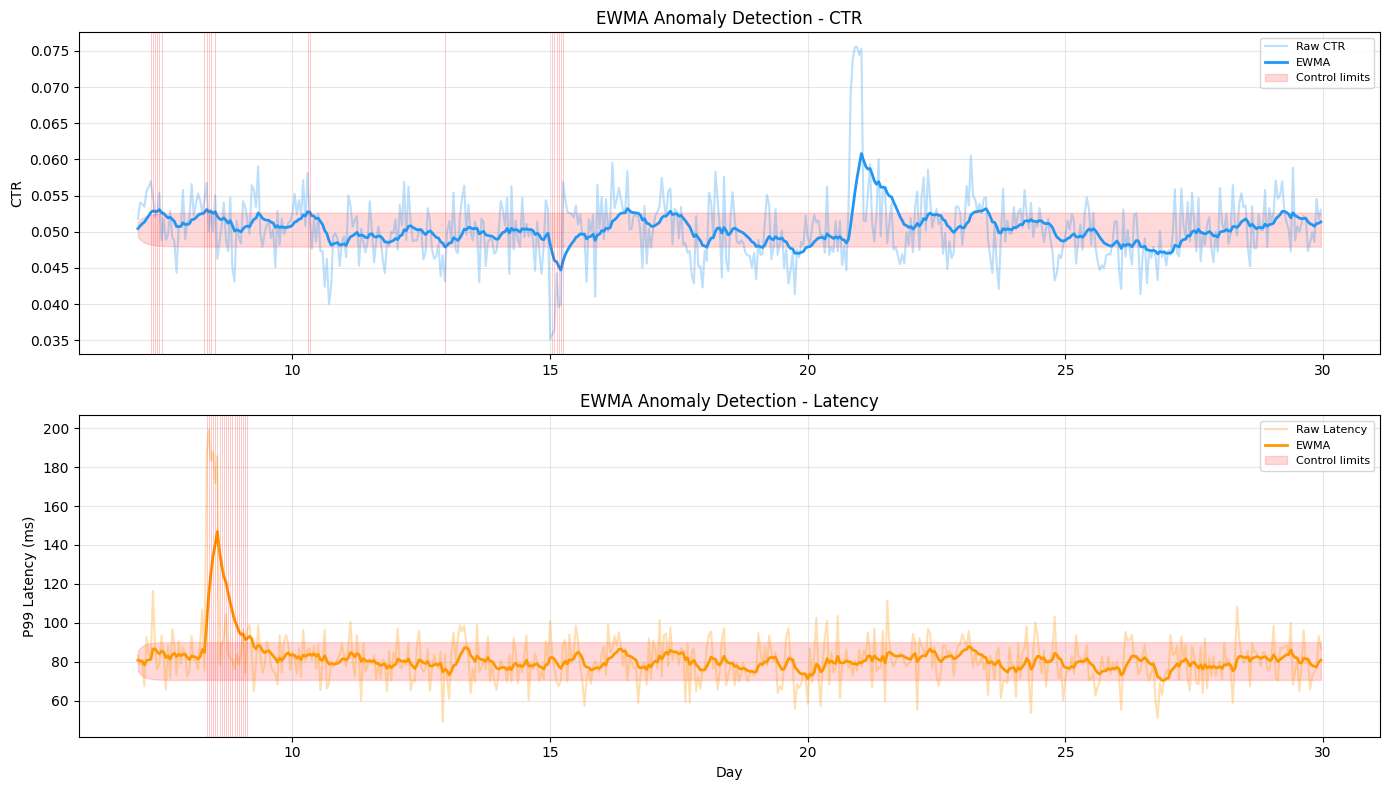

In [6]:
# EWMA anomaly detection

class EWMADetector:
    """EWMA-based anomaly detection."""

    def __init__(self, lambda_: float = 0.2, L: float = 3.0):
        self.lambda_ = lambda_
        self.L = L
        self.ewma = None
        self.mean = None
        self.std = None
        self.t = 0
        self.history = []

    def fit(self, training_data: np.ndarray):
        """Initialize with training data."""
        self.mean = np.mean(training_data)
        self.std = np.std(training_data)
        self.ewma = self.mean

    def update(self, value: float) -> Dict:
        self.t += 1
        old_ewma = self.ewma
        self.ewma = self.lambda_ * value + (1 - self.lambda_) * self.ewma

        # Control limits
        factor = self.L * self.std * np.sqrt(
            self.lambda_ / (2 - self.lambda_) * (1 - (1 - self.lambda_) ** (2 * self.t))
        )
        ucl = self.mean + factor
        lcl = self.mean - factor

        is_anomaly = self.ewma > ucl or self.ewma < lcl

        result = {
            "value": value,
            "ewma": self.ewma,
            "ucl": ucl,
            "lcl": lcl,
            "is_anomaly": is_anomaly
        }
        self.history.append(result)
        return result


# Apply EWMA detector to our metrics
np.random.seed(42)

# Use first 7 days for training, monitor remaining
train_hours = 7 * 24

ewma_ctr = EWMADetector(lambda_=0.1, L=3.0)
ewma_ctr.fit(ctr_series[:train_hours])

ewma_latency = EWMADetector(lambda_=0.15, L=3.0)
ewma_latency.fit(latency_series[:train_hours])

ctr_anomalies = []
latency_anomalies = []

for h in range(train_hours, n_hours):
    r_ctr = ewma_ctr.update(ctr_series[h])
    r_lat = ewma_latency.update(latency_series[h])
    if r_ctr["is_anomaly"]:
        ctr_anomalies.append(h)
    if r_lat["is_anomaly"]:
        latency_anomalies.append(h)

print(f"CTR anomalies detected: {len(ctr_anomalies)} hours")
print(f"Latency anomalies detected: {len(latency_anomalies)} hours")

# Visualize EWMA for CTR
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ewma_hours = range(train_hours, n_hours)
ewma_vals = [r["ewma"] for r in ewma_ctr.history]
ucl_vals = [r["ucl"] for r in ewma_ctr.history]
lcl_vals = [r["lcl"] for r in ewma_ctr.history]

axes[0].plot(np.array(list(ewma_hours))/24, ctr_series[train_hours:], alpha=0.3,
             color='#2196F3', label='Raw CTR')
axes[0].plot(np.array(list(ewma_hours))/24, ewma_vals, linewidth=2,
             color='#2196F3', label='EWMA')
axes[0].fill_between(np.array(list(ewma_hours))/24, lcl_vals, ucl_vals,
                     alpha=0.15, color='red', label='Control limits')
for ah in ctr_anomalies[:20]:
    axes[0].axvline(x=ah/24, color='red', alpha=0.3, linewidth=0.5)
axes[0].set_ylabel("CTR")
axes[0].set_title("EWMA Anomaly Detection - CTR")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Latency
ewma_vals_l = [r["ewma"] for r in ewma_latency.history]
ucl_vals_l = [r["ucl"] for r in ewma_latency.history]
lcl_vals_l = [r["lcl"] for r in ewma_latency.history]

axes[1].plot(np.array(list(ewma_hours))/24, latency_series[train_hours:], alpha=0.3,
             color='#FF9800', label='Raw Latency')
axes[1].plot(np.array(list(ewma_hours))/24, ewma_vals_l, linewidth=2,
             color='#FF9800', label='EWMA')
axes[1].fill_between(np.array(list(ewma_hours))/24, lcl_vals_l, ucl_vals_l,
                     alpha=0.15, color='red', label='Control limits')
for ah in latency_anomalies[:20]:
    axes[1].axvline(x=ah/24, color='red', alpha=0.3, linewidth=0.5)
axes[1].set_xlabel("Day")
axes[1].set_ylabel("P99 Latency (ms)")
axes[1].set_title("EWMA Anomaly Detection - Latency")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Root Cause Analysis Framework

When an alert fires, the on-call engineer needs to quickly identify the root cause. A systematic framework:

1. **Is it a data issue?** Check feature distributions, null rates, stale timestamps
2. **Is it a model issue?** Check model version, prediction distribution, AUC on holdout
3. **Is it a system issue?** Check latency, error rates, CPU/memory usage
4. **Is it external?** Check for holidays, major events, competitor actions

Decision tree:

```
Alert fires → Check error rate
  ├── Error rate high → System issue (check logs, deployments)
  └── Error rate normal → Check feature distributions
      ├── Features drifted → Data pipeline issue
      └── Features normal → Check prediction distribution
          ├── Predictions abnormal → Model issue (check recent model updates)
          └── Predictions normal → External factor (check calendar, news)
```

> **💡 Concept:** Meta's internal monitoring system automatically performs this triage. When a metric drops, it checks correlated signals and produces a ranked list of likely root causes, saving on-call engineers significant debugging time.

In [7]:
# Automated root cause analysis

class RootCauseAnalyzer:
    """Automated root cause analysis for rec system alerts."""

    def __init__(self):
        self.signal_checks = [
            ("System Error Rate", self._check_system_errors),
            ("Data Pipeline", self._check_data_pipeline),
            ("Feature Drift", self._check_feature_drift),
            ("Model Prediction Shift", self._check_prediction_shift),
            ("Traffic Pattern", self._check_traffic),
        ]

    def analyze(self, signals: Dict) -> List[Dict]:
        """Analyze signals and return ranked root causes."""
        findings = []
        for name, check_fn in self.signal_checks:
            result = check_fn(signals)
            if result["anomalous"]:
                findings.append({"cause": name, **result})

        # Rank by confidence
        findings.sort(key=lambda x: -x["confidence"])
        return findings

    def _check_system_errors(self, signals: Dict) -> Dict:
        error_rate = signals.get("error_rate", 0)
        return {
            "anomalous": error_rate > 0.01,
            "confidence": min(error_rate / 0.01, 1.0),
            "detail": f"Error rate: {error_rate:.2%}",
            "action": "Check service logs, recent deployments"
        }

    def _check_data_pipeline(self, signals: Dict) -> Dict:
        null_rate = signals.get("feature_null_rate", 0)
        staleness = signals.get("feature_staleness_hours", 0)
        anomalous = null_rate > 0.05 or staleness > 2
        confidence = max(null_rate / 0.05, staleness / 2) if anomalous else 0
        return {
            "anomalous": anomalous,
            "confidence": min(confidence, 1.0),
            "detail": f"Null rate: {null_rate:.2%}, Staleness: {staleness:.1f}h",
            "action": "Check ETL jobs, feature pipeline health"
        }

    def _check_feature_drift(self, signals: Dict) -> Dict:
        max_psi = signals.get("max_feature_psi", 0)
        return {
            "anomalous": max_psi > 0.2,
            "confidence": min(max_psi / 0.2, 1.0) if max_psi > 0.2 else 0,
            "detail": f"Max PSI: {max_psi:.4f}",
            "action": "Investigate drifted features, consider model retrain"
        }

    def _check_prediction_shift(self, signals: Dict) -> Dict:
        pred_psi = signals.get("prediction_distribution_psi", 0)
        return {
            "anomalous": pred_psi > 0.15,
            "confidence": min(pred_psi / 0.15, 1.0) if pred_psi > 0.15 else 0,
            "detail": f"Prediction PSI: {pred_psi:.4f}",
            "action": "Check model version, compare with previous model"
        }

    def _check_traffic(self, signals: Dict) -> Dict:
        traffic_change = signals.get("traffic_change_pct", 0)
        return {
            "anomalous": abs(traffic_change) > 0.20,
            "confidence": min(abs(traffic_change) / 0.20, 1.0) if abs(traffic_change) > 0.20 else 0,
            "detail": f"Traffic change: {traffic_change:+.1%}",
            "action": "Check for external events, marketing campaigns"
        }


# Simulate three scenarios
analyzer = RootCauseAnalyzer()

scenarios = [
    ("Scenario 1: Data Pipeline Failure", {
        "error_rate": 0.002,
        "feature_null_rate": 0.30,
        "feature_staleness_hours": 6.0,
        "max_feature_psi": 0.45,
        "prediction_distribution_psi": 0.25,
        "traffic_change_pct": 0.02,
    }),
    ("Scenario 2: Service Outage", {
        "error_rate": 0.15,
        "feature_null_rate": 0.01,
        "feature_staleness_hours": 0.5,
        "max_feature_psi": 0.05,
        "prediction_distribution_psi": 0.03,
        "traffic_change_pct": -0.05,
    }),
    ("Scenario 3: Holiday Traffic Spike", {
        "error_rate": 0.003,
        "feature_null_rate": 0.01,
        "feature_staleness_hours": 0.3,
        "max_feature_psi": 0.12,
        "prediction_distribution_psi": 0.08,
        "traffic_change_pct": 0.45,
    }),
]

for scenario_name, signals in scenarios:
    print(f"\n{'='*60}")
    print(f"{scenario_name}")
    print(f"{'='*60}")
    findings = analyzer.analyze(signals)
    for i, f in enumerate(findings):
        print(f"  [{i+1}] {f['cause']} (confidence: {f['confidence']:.0%})")
        print(f"      Detail: {f['detail']}")
        print(f"      Action: {f['action']}")


Scenario 1: Data Pipeline Failure
  [1] Data Pipeline (confidence: 100%)
      Detail: Null rate: 30.00%, Staleness: 6.0h
      Action: Check ETL jobs, feature pipeline health
  [2] Feature Drift (confidence: 100%)
      Detail: Max PSI: 0.4500
      Action: Investigate drifted features, consider model retrain
  [3] Model Prediction Shift (confidence: 100%)
      Detail: Prediction PSI: 0.2500
      Action: Check model version, compare with previous model

Scenario 2: Service Outage
  [1] System Error Rate (confidence: 100%)
      Detail: Error rate: 15.00%
      Action: Check service logs, recent deployments

Scenario 3: Holiday Traffic Spike
  [1] Traffic Pattern (confidence: 100%)
      Detail: Traffic change: +45.0%
      Action: Check for external events, marketing campaigns


## Exercises

### 🏋️ Exercise 1: Build a Monitoring Dashboard

Build a complete monitoring system that tracks multiple metrics, detects anomalies, and provides root cause suggestions.

In [8]:
# 🏋️ Exercise 1: Complete monitoring dashboard

class RecSystemMonitor:
    """Complete monitoring system for a recommendation service."""

    def __init__(self):
        # TODO: Initialize
        # 1. Drift detector for input features
        # 2. EWMA detectors for key metrics (CTR, AUC, latency, error rate)
        # 3. Root cause analyzer
        # 4. Alert history
        pass

    def ingest(self, timestamp: int, features: Dict[str, np.ndarray],
               metrics: Dict[str, float]):
        # TODO: Process incoming data
        # 1. Check feature drift
        # 2. Check metric anomalies
        # 3. If anomaly detected, run root cause analysis
        # 4. Generate alerts with severity levels
        pass

    def get_dashboard(self) -> Dict:
        # TODO: Return dashboard data
        # - Current metric values with trend (up/down/stable)
        # - Active alerts with severity
        # - Drift status per feature
        pass


# TODO: Simulate 30 days with injected issues:
# Day 5: Feature pipeline delay (2 hours stale)
# Day 12: Model update with slight regression
# Day 18: Traffic spike (holiday)
# Day 25: Gradual concept drift
# Verify that the monitor catches each issue

### 🏋️ Exercise 2: Multi-Metric Anomaly Detection

Implement a system that detects correlated anomalies across multiple metrics (e.g., latency spike + error rate spike = system issue).

In [9]:
# 🏋️ Exercise 2: Correlated anomaly detection

# TODO: Implement a detector that:
# 1. Monitors N metrics independently
# 2. When any single metric fires, checks correlated metrics
# 3. Classifies the anomaly as:
#    - System issue (latency + errors correlated)
#    - Data issue (feature drift + prediction shift correlated)
#    - Model issue (AUC drop without feature drift)
#    - External (traffic change without system issues)
# 4. Reports the classification with evidence

### 🏋️ Exercise 3: Seasonal-Aware Drift Detection

Implement a drift detector that accounts for known seasonal patterns (weekday/weekend, time of day).

In [10]:
# 🏋️ Exercise 3: Seasonal drift detection

# TODO: Implement a drift detector that:
# 1. Learns hourly and weekly patterns from reference data
# 2. De-seasonalizes current data before drift testing
# 3. Computes PSI on de-seasonalized data
# This avoids false alarms from normal weekend/weekday shifts

## Summary

Key takeaways:

1. **Data drift detection** (PSI, KS test) catches distribution shifts before they degrade model quality
2. **Multiple monitoring layers** are needed: data quality, model quality, system health, business metrics
3. **EWMA-based anomaly detection** adapts to trends while maintaining sensitivity to sudden changes
4. **Automated root cause analysis** accelerates incident response from hours to minutes
5. **Correlated anomaly detection** across metrics helps distinguish system issues from data issues from model issues

### References

- Breck et al., "Data Validation for Machine Learning" (2019, Google, MLSys)
- Polyzotis et al., "Data Lifecycle Challenges in Production Machine Learning" (2018, Google, SIGMOD)
- Schelter et al., "Automating Large-Scale Data Quality Verification" (2018, Amazon, VLDB)
- Lu et al., "Learning under Concept Drift: A Review" (2020, Survey)